In [3]:
import pandas as pd

df = pd.DataFrame({

    'journey_type': [
        #onboarding
        'Onboarding','Onboarding','Onboarding','Onboarding','Onboarding',
        'Onboarding','Onboarding','Onboarding','Onboarding','Onboarding',
        'Onboarding','Onboarding','Onboarding','Onboarding','Onboarding',

        # plan change
        'Plan Change','Plan Change',
        #topup
        'Top-up','Top-up',
        #migration
        'Migration','Migration',
        #adding addon
        'Add-on','Add-on',
        #post validation
        'Post Validation','Post Validation'
    ],

    'step_name': [
         #onboarding steps
        'App Install','App Launch','Login Options','Email Selection',
        'Send OTP/Link','Email Verification','Onboarding Page',
        'Plan Selection','Prepaid/Postpaid Selection','Number Selection',
        'KYC Verification','Payment Page','Enter Payment',
        'Payment Success','Activation & Dashboard',

        # plan change steps
        'View Plans','Apply New Plan',
        #topup steps
        'Enter Amount','Payment',
        #migration steps
        'Select Plan','KYC',
        #adding addon steps
        'Select Addon','Activation',
        #post validation steps
        'Check Plan Details','Check Benefits'
    ],

    'expected_value': [
        # onboarding expected 
        'App installed','App opens','Options displayed','Email selected',
        'OTP/link sent','Email verified','Page loaded',
        'Plans displayed','Option selected','Numbers displayed',
        'KYC success','Payment page shown','Payment initiated',
        'Payment success','Customer activated with plan details',

        # plan change expected
        'Plans visible','Plan updated',
        #toup expected
        'Amount accepted','Top-up success',
        #migration expected
        'Plans displayed','KYC success',
        #adding addon expected
        'Addon selected','Addon activated',
        #post validation expected
        'Correct plan shown','Benefits correct'
    ],

    'actual_value': [
        # onboarding actual defects
        'App installed','App crash','Options displayed','Email selected',
        'OTP not received','Email verified','Page loaded',
        'Plans missing','Option selected','Numbers not displayed',
        'KYC failed','Payment page shown','Payment failed',
        'Payment success','Plan details missing',

        # plan change actual defects
        'Plans visible','Wrong plan applied',
        #topup actual defects
        'Amount accepted','Top-up failed',
        #migration actual defects
        'Plans displayed','KYC failed',
        #adding add on actual defects
        'Addon selected','Not activated',
        #post validation actual defects
        'Wrong plan shown','Benefits missing'
    ],

    'severity': [
        # Onboarding defects SEVERITY
        'Low','Critical','Low','Low','High','Low','Low',
        'High','Low','High','Critical','Low','Critical','Low','High',

        # plan change defect SEVERITY
        'Low','High',
        #topup defect SEVERITY
        'Low','Critical',
        #migration defect SEVERITY
        'Low','Critical',
        #addon defect SEVERITY
        'Low','High',
        #post validation defect SEVERITY
        'High','Medium'
    ],

    'status': [
        # onboarding defect STATUS
        'Closed','Open','Closed','Closed','Open','Closed','Closed',
        'Open','Closed','Open','Open','Closed','Open','Closed','Open',

        # plan change defect STATUS
        'Closed','Open',
        # topup defect STATUS
        'Closed','Open',
        # migration defect STATUS
        'Closed','Open',
        # addon defect STATUS
        'Closed','Open',
        # post validation defect STATUS
        'Open','Open'
    ]
})

In [4]:
df

,journey_type,step_name,expected_value,actual_value,severity,status
0,Onboarding,App Install,App installed,App installed,Low,Closed
1,Onboarding,App Launch,App opens,App crash,Critical,Open
2,Onboarding,Login Options,Options displayed,Options displayed,Low,Closed
3,Onboarding,Email Selection,Email selected,Email selected,Low,Closed
4,Onboarding,Send OTP/Link,OTP/link sent,OTP not received,High,Open
5,Onboarding,Email Verification,Email verified,Email verified,Low,Closed
6,Onboarding,Onboarding Page,Page loaded,Page loaded,Low,Closed
7,Onboarding,Plan Selection,Plans displayed,Plans missing,High,Open
8,Onboarding,Prepaid/Postpaid Selection,Option selected,Option selected,Low,Closed
9,Onboarding,Number Selection,Numbers displayed,Numbers not displayed,High,Open


In [5]:
#information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   journey_type    25 non-null     object
 1   step_name       25 non-null     object
 2   expected_value  25 non-null     object
 3   actual_value    25 non-null     object
 4   severity        25 non-null     object
 5   status          25 non-null     object
dtypes: object(6)
memory usage: 1.3+ KB


In [7]:
#checking the null value
df.isnull().sum()

journey_type      0
step_name         0
expected_value    0
actual_value      0
severity          0
status            0
dtype: int64

In [8]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [12]:
#defect logic
df['defect_flag'] = (
    df['expected_value'].notna() &
    df['actual_value'].notna() &
    (df['expected_value'] != df['actual_value'])
)

In [14]:
#check the defects
df[['step_name','expected_value','actual_value','defect_flag']]

,step_name,expected_value,actual_value,defect_flag
0,App Install,App installed,App installed,False
1,App Launch,App opens,App crash,True
2,Login Options,Options displayed,Options displayed,False
3,Email Selection,Email selected,Email selected,False
4,Send OTP/Link,OTP/link sent,OTP not received,True
5,Email Verification,Email verified,Email verified,False
6,Onboarding Page,Page loaded,Page loaded,False
7,Plan Selection,Plans displayed,Plans missing,True
8,Prepaid/Postpaid Selection,Option selected,Option selected,False
9,Number Selection,Numbers displayed,Numbers not displayed,True


In [16]:
#counting defects per journey and here onboarding journey having more defects compared to other journey
df.groupby('journey_type')['defect_flag'].sum()

journey_type
Add-on             1
Migration          1
Onboarding         7
Plan Change        1
Post Validation    2
Top-up             1
Name: defect_flag, dtype: int64

In [18]:
#identifying the steps where exactly its failed
df[df['defect_flag'] == True][['journey_type','step_name']]

,journey_type,step_name
1,Onboarding,App Launch
4,Onboarding,Send OTP/Link
7,Onboarding,Plan Selection
9,Onboarding,Number Selection
10,Onboarding,KYC Verification
12,Onboarding,Enter Payment
14,Onboarding,Activation & Dashboard
16,Plan Change,Apply New Plan
18,Top-up,Payment
20,Migration,KYC


In [19]:
#high priority for critical defects
df[df['severity'] == 'Critical']

,journey_type,step_name,expected_value,actual_value,severity,status,defect_flag
1,Onboarding,App Launch,App opens,App crash,Critical,Open,True
10,Onboarding,KYC Verification,KYC success,KYC failed,Critical,Open,True
12,Onboarding,Enter Payment,Payment initiated,Payment failed,Critical,Open,True
18,Top-up,Payment,Top-up success,Top-up failed,Critical,Open,True
20,Migration,KYC,KYC success,KYC failed,Critical,Open,True


In [20]:
#defects by severity
df.groupby('severity')['defect_flag'].sum()

severity
Critical    5
High        7
Low         0
Medium      1
Name: defect_flag, dtype: int64

In [22]:
#open and closed defects
df.groupby('status')['defect_flag'].sum()

status
Closed     0
Open      13
Name: defect_flag, dtype: int64

In [23]:
3which journey having critical defects
df[df['severity']=='Critical'].groupby('journey_type')['defect_flag'].sum()

journey_type
Migration     1
Onboarding    3
Top-up        1
Name: defect_flag, dtype: int64

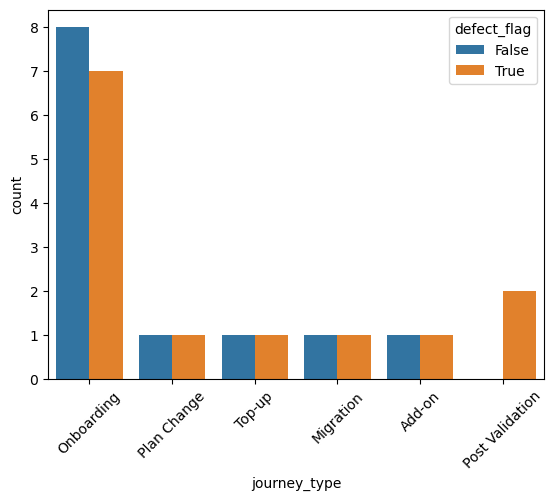

In [26]:
#visualization
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='journey_type', hue='defect_flag', data=df)
plt.xticks(rotation=45)
plt.show()

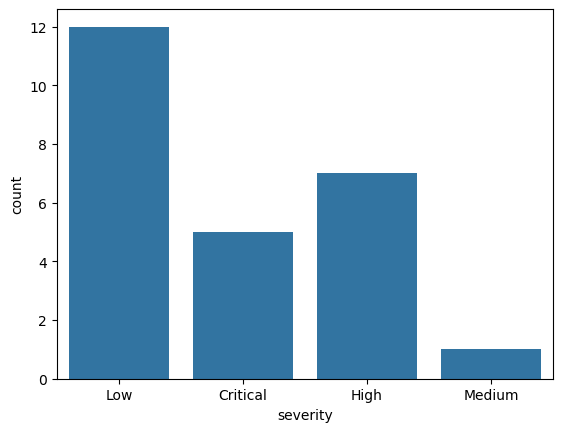

In [27]:
#severity distribution
sns.countplot(x='severity', data=df)
plt.show()

In [ ]:
#“Onboarding flow has the highest defects, especially in OTP, KYC, and payment stages”
#“Critical defects are mainly in payment and KYC, which are high-risk”
#“There are open defects indicating backlog issues”
#“Mismatch between expected and actual values helped identify defects programmatically”

In [ ]:
'''I built a telecom defect analysis project where I modeled real customer journeys, 
identified defects using expected vs actual comparison, 
and analyzed high-risk areas using Pandas and visualization.'''